In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
from scipy.stats import norm
from sklearn.neighbors import KernelDensity

Insurance Dataset : https://docs.google.com/spreadsheets/d/1dAc3E4U-gBzihJ6HLM2kYVDAqQthdReg20zwwaplTW8/edit?usp=share_link

In [25]:
df = pd.read_csv('Data\insurance_data.csv',index_col = 0)

In [26]:
df.head()

,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
index,,,,,,,,,,
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


### Q-1: What is the probability distribution of age in the insurance dataset?

-- Find out using the KDE method

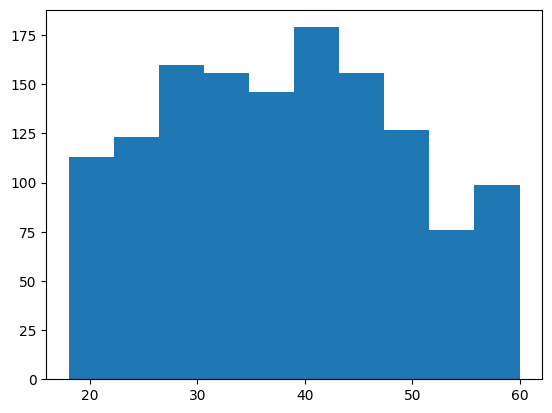

In [30]:
# Using Histogram

plt.hist(df['age'],bins=10)
plt.show()

#feels like normal distribution of the data

<Axes: xlabel='age', ylabel='Density'>

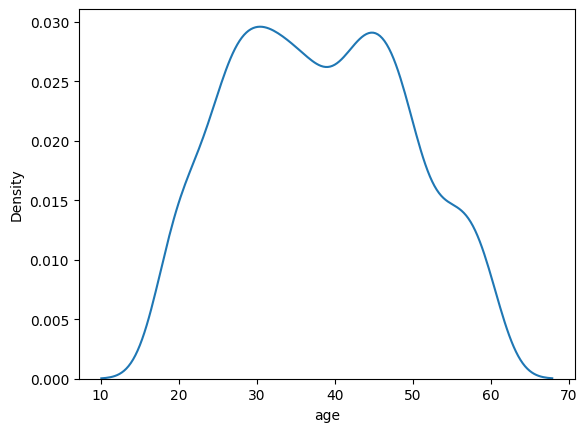

In [31]:
#main technique using kde

sns.kdeplot(data = df,x = 'age')
#Feels like normal distribution

In [74]:
#step by step technique

#KDE for the data
sample = np.reshape(df['age'].dropna(),shape = (len(df['age'].dropna()),1))
print(sample.shape)

(1335, 1)


In [77]:
model = KernelDensity(bandwidth = 3,kernel='gaussian')
model.fit(sample)

KernelDensity(bandwidth=3)

In [78]:
values = np.linspace(sample.min(),sample.max(),100)
values = values.reshape((len(values),1))

In [79]:
probablities = model.score_samples(values)
probablities = np.exp(probablities)

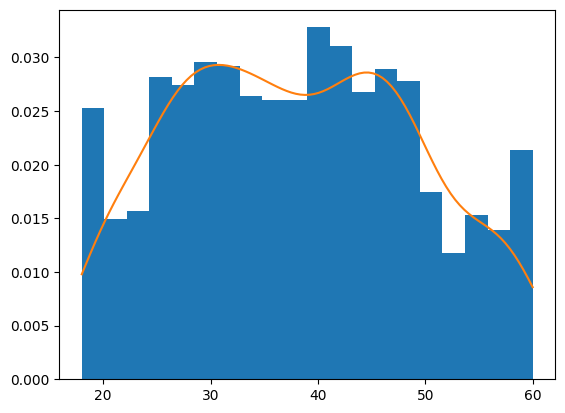

In [80]:
#plotting the graph

plt.hist(sample,bins = 20,density=True)
plt.plot(values,probablities)

### Q-2: What is the probability of a patient having a BMI greater than 30?

In [32]:
(df['bmi']>30).value_counts()/np.sum((df['bmi']>30).value_counts())

bmi
True     0.521642
False    0.478358
Name: count, dtype: float64

### Q-3: Plot distribution plot of claim for Smoker and non smoker. What changes you see in the plot?

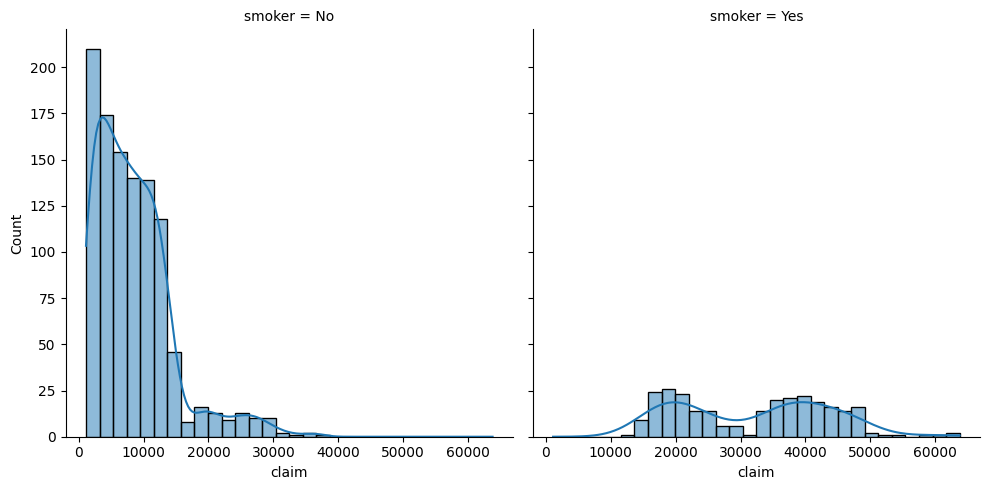

In [81]:
sns.displot(data=df,x='claim',col= 'smoker',kind='hist',kde= True)

#Observation 
#Non Smoker - Data is not much ranged on the smoker side you are having wide range of data
#Non Smoker is feels like normal distributed data while smoker it is two peak data distribution

### Q-4: Plot the 2D probability density plot of claim and age in the insurance dataset?

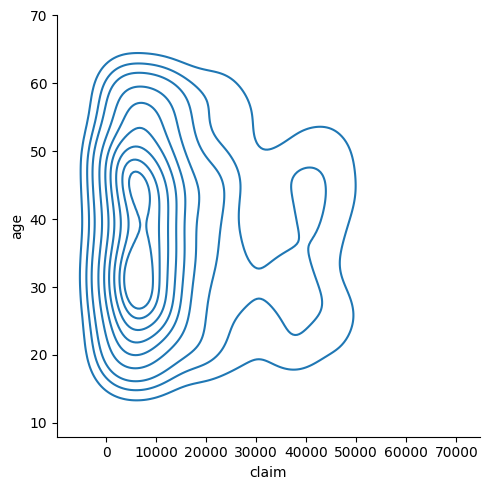

In [34]:
sns.displot(data = df,x='claim',y = 'age',kind='kde')

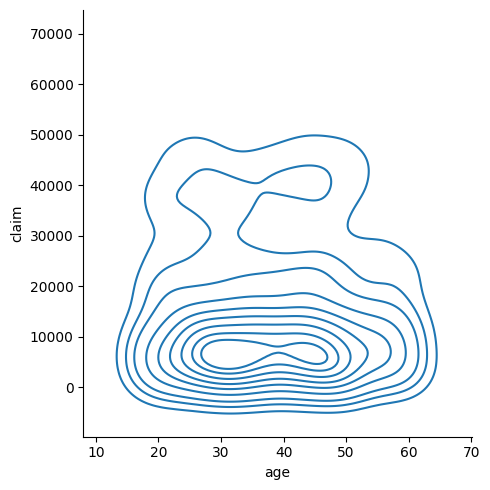

In [35]:
sns.displot(data = df,x='age',y='claim',kind='kde')

### Q-5: How does the disribution of claim changes for different region? Plot density plot and note down the observations

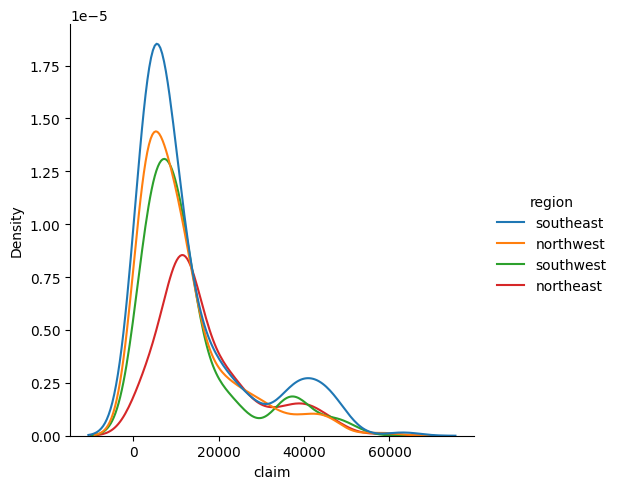

In [82]:
sns.displot(data = df,x='claim',hue='region',kind='kde')

In [ ]:
#Southeast - it has the highet peak among the data means that most of the people in the southeast region has filed the average claim
#Northeast region has the lowest average claim 

### Q6: Plot PDF and CDF of claim in insurance data

<Axes: ylabel='Frequency'>

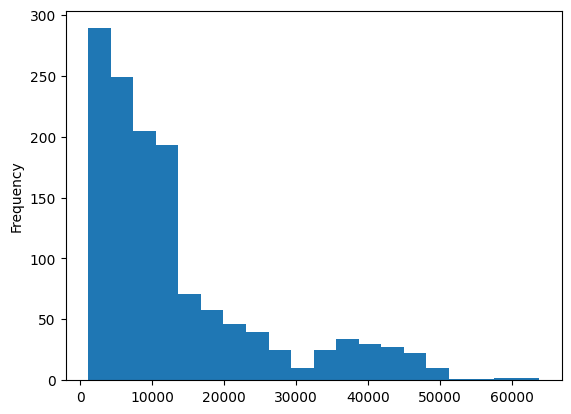

In [83]:
df['claim'].plot(kind='hist',bins=20) #it is not following any distribution feels like left skewed distribution

In [84]:
#non parameteric Density Estimation
df_std = df['claim'].std()
from sklearn.neighbors import KernelDensity
model = KernelDensity(bandwidth=3,kernel='gaussian')

In [86]:
sample = np.reshape(df['claim'],shape=(len(df['claim']),1))

In [87]:
#it expect data in a 2d form

model.fit(sample)

KernelDensity(bandwidth=3)

In [88]:
values = np.linspace(sample.min(),sample.max(),1000)
values = values.reshape((len(values),1))

In [89]:
probablities = model.score_samples(values)
probablities = np.exp(probablities)

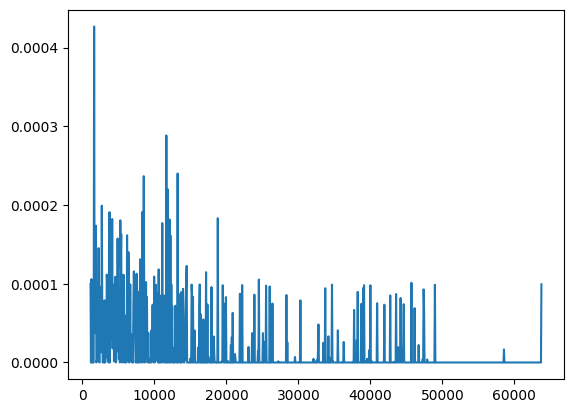

In [90]:
# plt.hist(df['claim'],bins=20,density= True)
plt.plot(values[:],probablities)
plt.show()

<Axes: ylabel='Density'>

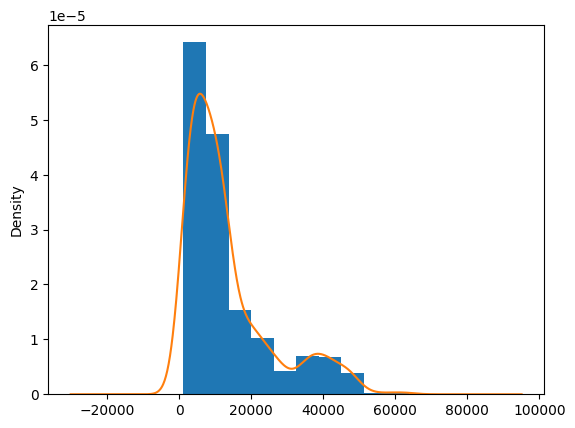

In [90]:
df['claim'].plot(kind='hist',density= True)
df['claim'].plot(kind='kde')

In [ ]:
# Parametric Density Estimation
# (1) It is assumed as chi Square
sample_mean = sample.mean()
sample_std = sample.std()

In [39]:
from scipy.stats import chisquare
dist = chisquare(sample)

In [ ]:
values = np.linspace(sample.min(),sample.max(),1000)

Power_divergenceResult(statistic=array([14816136.70043354]), pvalue=array([0.]))

In [44]:
from scipy.stats import power_divergence
probablity = power_divergence(values, lambda_='log-likelihood')

In [46]:
probablity

Power_divergenceResult(statistic=np.float64(11511126.891857138), pvalue=np.float64(0.0))

In [ ]:
plt.hist(sample,bins=20,density = True)
plt.plot(values,probablity)

### Q-7: Given a probability density function f(x) = 2x for 0 <= x <= 1 and f(x) = 0 otherwise, compute the cumulative distribution function F(x) and plot it. Use this to find the probability that X is greater than 0.5.

In [ ]:
# code here

### Q-8: In a manufacturing process, the thickness of a certain material is known to be normally distributed with a mean of 1.2 mm and a standard deviation of 0.05 mm. What is the probability density function of the thickness? Plot the PDF and use it to compute the probability that the thickness is between 1.1 mm and 1.3 mm.

In [2]:
thick_mean = 1.2 #mm
thick_std = 0.05 #mm

In [3]:
from scipy.stats import norm

dist = norm(thick_mean,thick_std)

In [18]:
sample = np.linspace(1.1,1.3,100)

In [13]:
probablity = [dist.pdf(value) for value in sample]

In [ ]:
probablity

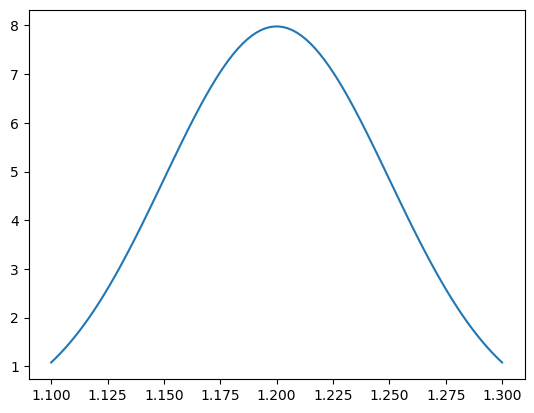

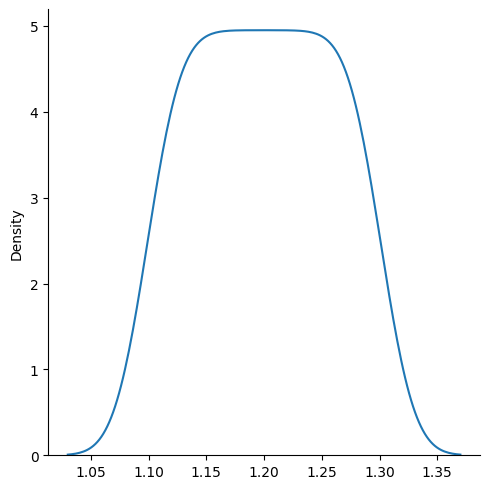

In [22]:
# plt.hist(sample,bins= 20)
plt.plot(sample,probablity)
sns.displot(sample,kind='kde')
plt.show()

### Q-9 : A data scientist is investigating the distribution of customer ages in a retail store. She collects a sample of 100 ages and estimates the probability density function using kernel density estimation. What bandwidth should she choose to obtain the best estimate?

In [ ]:
# Standard deviation of those datas will give you the perfect bandwidth to calculate kernal density 